# Section 2 — Modern Machine Learning Techniques

Regularised linear regression (Ridge, Lasso), tree ensembles (Random Forest, CatBoost), feed-forward neural networks, and agglomerative hierarchical clustering — fit, evaluate, and compared against the Section 1 baselines on the same two insurance datasets.

Part of the EAA seminar *Machine Learning & Generative AI: A Hands-On Guide to Actuarial Practice* by Dr. Simon Hatzesberger (8–9 June 2026, Munich).

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/simonhatzesberger/ml-genai-actuarial-practice/blob/main/notebooks/02_modern_ml_techniques/02_modern_ml_techniques.ipynb)

Repository: [simonhatzesberger/ml-genai-actuarial-practice](https://github.com/simonhatzesberger/ml-genai-actuarial-practice) — Code under the [MIT License](https://github.com/simonhatzesberger/ml-genai-actuarial-practice/blob/main/LICENSE).


We will pick up exactly where Section 1 stopped. The same two datasets — **medical insurance** (regression) and **car insurance** (classification + clustering) — make every modern method directly comparable with the classical baselines. Four methods, four pay-offs:

1. **Regularised linear regression** (Ridge, Lasso) — controls overfitting and performs variable selection on the medical-cost regression.
2. **Tree ensembles** (Random Forest, CatBoost) — averages or boosts many trees to recover the calibration that a single tree lacked on the car-insurance classification.
3. **Feed-forward neural network** (a small MLP) — captures arbitrary non-linearities at the cost of interpretability.
4. **Agglomerative hierarchical clustering** — produces a *dendrogram* of merges that does not require fixing K up front, on the same car-insurance portfolio used in Section 1's k-means.
5. **Individual claims reserving**

## Contents

- [Learning objectives](#learning-objectives)
- [Setup](#setup)
- [1. Regularised linear regression — Ridge and Lasso on medical charges](#1-regularised-linear-regression)
- [2. Tree ensembles — Random Forest and CatBoost on car-insurance claims](#2-tree-ensembles)
- [3. Feed-forward neural network on car-insurance claims](#3-feed-forward-neural-network)
- [4. Agglomerative hierarchical clustering on the car-insurance portfolio](#4-agglomerative-hierarchical-clustering)
- [5. Individual claims reserving](#5-individual-claims-reserving)
- [Exercises](#exercises)
- [Summary](#summary)
- [Next steps](#next-steps)
- [References](#references)


## Learning objectives

By the end of this notebook you will be able to:

- explain when and why to use Ridge vs. Lasso regularisation, and read the *coefficient path* as a function of the penalty strength;
- fit a Random Forest and a CatBoost model on tabular data, compare them to a logistic baseline on log-loss and calibration;
- recognise when a small feed-forward neural network is worth the extra complexity over a GLM;
- run agglomerative hierarchical clustering, read a dendrogram, and contrast it with k-means.


## Setup

The cell below detects whether you are on Google Colab. On Colab it installs the section's pinned dependencies and downloads the two datasets used throughout the notebook.


In [ ]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q -r https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/02_modern_ml_techniques/requirements.txt
    !mkdir -p data
    !wget -q -O data/data_medical_cost.csv  https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/02_modern_ml_techniques/data/data_medical_cost.csv
    !wget -q -O data/data_car_insurance.csv https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/02_modern_ml_techniques/data/data_car_insurance.csv

SEED = 42

print(f"Setup complete. Environment: {'Colab' if IN_COLAB else 'local'}.")


Setup complete. Environment: local.


The same palette and seaborn theme as Section 1.


In [2]:
# Standard scientific-Python stack: arrays, dataframes, plotting.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# A small brand palette so every figure shares a consistent look.
PRIMARY      = "#1F3A6E"
ACCENT_RED   = "#C0504D"
ACCENT_GREEN = "#4E7C59"
GRAY_TEXT    = "#404040"

# Apply the palette + a clean white grid theme to every figure below.
sns.set_theme(
    style="whitegrid",
    palette=[PRIMARY, ACCENT_RED, ACCENT_GREEN, "#7A8DA8", "#9C7A7A"],
    rc={
        "axes.edgecolor":   GRAY_TEXT,
        "axes.labelcolor":  GRAY_TEXT,
        "xtick.color":      GRAY_TEXT,
        "ytick.color":      GRAY_TEXT,
        "axes.titlecolor":  PRIMARY,
        "axes.titleweight": "bold",
        "grid.color":       "#E5E5E5",
        "figure.facecolor": "white",
        "axes.facecolor":   "white",
    },
)

# Seed NumPy so the (stochastic) models below are reproducible.
np.random.seed(SEED)


## 1. Regularised linear regression

Ordinary least squares (OLS) chases every wiggle of the training data, which inflates the coefficients of correlated or noisy features. The remedy is to add a penalty on coefficient size to the loss:

- **Ridge** (L²): shrinks all coefficients smoothly toward zero, never exactly to zero.
- **Lasso** (L¹): shrinks coefficients and *snaps some to exactly zero* — i.e. it performs implicit variable selection.

The geometric intuition: the Ridge constraint region is a smooth ball (the optimum slides along the curve), while the Lasso region is a diamond with corners on the axes (the optimum lands on a corner whenever it can, zeroing one or more coefficients).

We re-use the medical-cost regression task from Section 1.


In [3]:
# Load the medical-cost regression data; target = annual insurance charge.
df_reg = pd.read_csv("data/data_medical_cost.csv")
target_reg = "charges"
X_reg = df_reg.drop(columns=[target_reg])
y_reg = df_reg[target_reg]

# Hold out 20% for an honest final estimate; fit only on the other 80%.
from sklearn.model_selection import train_test_split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=SEED
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

cat_cols_r = ["sex", "smoker", "region"]
num_cols_r = ["age", "bmi", "children"]

# Standardise numerics so the penalty hits every coefficient on the same scale,
# and one-hot encode the categoricals. (Standardising is essential for Ridge/Lasso.)
preprocess_reg = ColumnTransformer([
    ("num", StandardScaler(),                       num_cols_r),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_r),
])
preprocess_reg.fit(X_train_r)

# Human-readable names for the transformed feature columns (used as plot labels).
feature_names_r = (
    num_cols_r
    + list(preprocess_reg.named_transformers_["cat"].get_feature_names_out(cat_cols_r))
)

print(f"train: {X_train_r.shape}   test: {X_test_r.shape}")


train: (1070, 6)   test: (268, 6)


### Coefficient paths — how Ridge and Lasso differ as we sweep the penalty


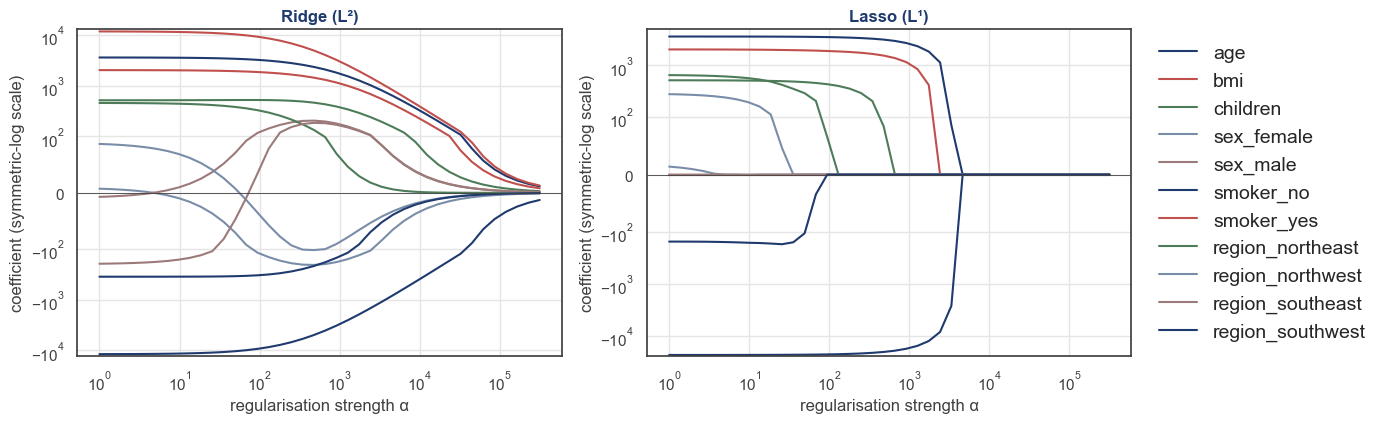

In [4]:
from sklearn.linear_model import Ridge, Lasso

# Sweep the penalty strength alpha over a wide log-spaced grid and record every
# coefficient at every alpha. The grid runs from 1 up to ~3e5 so we can watch
# each coefficient shrink all the way to its limit.
path_alphas = np.logspace(0, 5.5, 40)          # 1 ... ~316000
ridge_paths = np.zeros((len(path_alphas), len(feature_names_r)))
lasso_paths = np.zeros_like(ridge_paths)

# Pre-transform the training features once (standardise + one-hot).
X_train_t = preprocess_reg.transform(X_train_r)

# Refit Ridge and Lasso at each alpha and store the resulting coefficients.
for j, alpha in enumerate(path_alphas):
    ridge_paths[j] = Ridge(alpha=alpha).fit(X_train_t, y_train_r).coef_
    lasso_paths[j] = Lasso(alpha=alpha, max_iter=20_000).fit(X_train_t, y_train_r).coef_

# One line per feature. The smoker coefficient dwarfs the rest on the
# standardised scale, so we use a symmetric-log y-axis (linear near zero,
# logarithmic further out) to keep every feature visible -- including the
# small ones whose drop-out is the whole point of the Lasso panel.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for ax, paths, title in zip(axes, [ridge_paths, lasso_paths], ["Ridge (L²)", "Lasso (L¹)"]):
    for k, name in enumerate(feature_names_r):
        ax.plot(path_alphas, paths[:, k], lw=1.5, label=name)
    ax.set_xscale("log")
    ax.set_yscale("symlog", linthresh=100)     # show large & small coefficients together
    ax.axhline(0, color=GRAY_TEXT, lw=0.6)     # zero line: where Lasso coefficients land
    ax.set_xlabel("regularisation strength α")
    ax.set_ylabel("coefficient (symmetric-log scale)")
    ax.set_title(title)
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=14, frameon=False)
fig.tight_layout()
plt.show()


**Reading the paths.** *(The y-axis uses a symmetric-log scale — linear near zero, logarithmic further out — because the smoker coefficient dwarfs the others on the standardised scale; this keeps every feature visible.)*

- *Ridge (left).* Every coefficient shrinks **smoothly** toward zero as α grows, but none ever reaches exactly zero — even under heavy regularisation each feature keeps a small slice of the credit.
- *Lasso (right).* Coefficients hit **exactly zero one at a time** and then stay there. On this data the redundant `sex` and `smoker_yes` dummies vanish almost immediately, then the `region` dummies drop, then `children`, then `bmi`, then `age` — and the smoker flag (`smoker_no`) is the **last coefficient still standing** before it, too, is shrunk away. That ordering echoes the dominance of smoking — and then age and BMI — that we saw in the Section 1 coefficient and importance tables.

In actuarial practice the Lasso path doubles as a *feature-importance ranking*: the longer a coefficient survives as α grows, the more strongly the data insist on keeping it.


### Picking α by cross-validation


In [5]:
from sklearn.linear_model import RidgeCV, LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Small helper: RMSE / MAE / R² in one row, for stacking models into a table.
def metrics(y_true, y_pred, label):
    return pd.DataFrame({
        "RMSE": [np.sqrt(mean_squared_error(y_true, y_pred))],
        "MAE":  [mean_absolute_error(y_true, y_pred)],
        "R²":   [r2_score(y_true, y_pred)],
    }, index=[label])

# A wide alpha grid for cross-validation. It includes very small values so CV is
# free to choose almost no regularisation if that generalises best.
cv_alphas = np.logspace(-2, 3, 40)

# Fit three models: plain OLS, Ridge (alpha picked by CV), Lasso (alpha by CV).
ols   = Pipeline([("p", preprocess_reg), ("m", LinearRegression())]).fit(X_train_r, y_train_r)
ridge = Pipeline([("p", preprocess_reg), ("m", RidgeCV(alphas=cv_alphas))]).fit(X_train_r, y_train_r)
lasso = Pipeline([("p", preprocess_reg), ("m", LassoCV(alphas=cv_alphas, max_iter=20_000, random_state=SEED))]).fit(X_train_r, y_train_r)

# Predict on the held-out test set.
y_pred_ols   = ols.predict(X_test_r)
y_pred_ridge = ridge.predict(X_test_r)
y_pred_lasso = lasso.predict(X_test_r)

# The chosen alphas appear in each row label for reference.
table = pd.concat([
    metrics(y_test_r, y_pred_ols,   "OLS (Section 1)"),
    metrics(y_test_r, y_pred_ridge, f"Ridge  (α={ridge.named_steps['m'].alpha_:.3g})"),
    metrics(y_test_r, y_pred_lasso, f"Lasso  (α={lasso.named_steps['m'].alpha_:.3g})"),
])
table.style.format({"RMSE": "{:,.0f}", "MAE": "{:,.0f}", "R²": "{:.3f}"})


,RMSE,MAE,R²
OLS (Section 1),"5,796","4,181",0.784
Ridge (α=0.838),"5,798","4,186",0.783
Lasso (α=70.2),"5,837","4,227",0.781


**Reading the comparison.** On a *small* dataset like the medical-cost portfolio with only six raw features, regularisation buys very little — the OLS solution is not over-parameterised, so there is nothing to shrink. Ridge and Lasso land within a hundred dollars or so of OLS on every metric. The regularised models earn their keep in *higher-dimensional* settings — exactly the kind of book a credibility-style actuarial pricing model produces after one-hot encoding tariff classes, vehicle codes, occupation strings, and so on.


### Lasso's selected features at the cross-validated α


In [6]:
# List each coefficient at the CV-chosen alpha; flag which survived (non-zero).
lasso_coef = pd.DataFrame({
    "coef": lasso.named_steps["m"].coef_,
}, index=feature_names_r)
lasso_coef["selected"] = lasso_coef["coef"].abs() > 1e-8
lasso_coef.sort_values("coef", key=np.abs, ascending=False).round(2)


,coef,selected
smoker_no,-23213.34,True
age,3548.63,True
bmi,1928.30,True
children,455.80,True
region_northeast,195.96,True
region_southwest,-26.48,True
sex_female,-0.00,False
smoker_yes,0.00,False
sex_male,0.00,False
region_northwest,0.00,False


**What Lasso selected.** At the cross-validated α (around 70 on this data), Lasso keeps `age`, `bmi`, `children`, the smoker flag (`smoker_no`), and two of the four `region` dummies — and zeros the rest. Notice the symmetry trick on the smoker pair: because `smoker_yes` and `smoker_no` carry the same information (they sum to 1), Lasso keeps **one** of them and drops the other. On a regulatory submission with 200 covariates, the same mechanism would shrink the model to a defensible 20–30-feature core.


## 2. Tree ensembles — Random Forest and CatBoost on car-insurance claims

A single decision tree captures non-linearities and interactions for free, but it is *unstable* (small data changes can flip its splits) and its probabilities are *not well calibrated* — we saw both in Section 1. The remedy is to combine many trees:

- **Bagging / Random Forest** — train many trees on different bootstrap samples of the data and average their predictions. Reduces variance dramatically; calibration usually recovers.
- **Boosting / Gradient boosting** (here CatBoost) — train trees sequentially, each one fitting the residual error of the ensemble built so far. Reduces both bias and variance; usually the strongest off-the-shelf method on tabular data.

We rerun the car-insurance classification from Section 1 with both ensembles, keeping the logistic regression as a reference baseline.


In [7]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, f1_score, accuracy_score
from sklearn.calibration import CalibrationDisplay

df_cls = pd.read_csv("data/data_car_insurance.csv").drop(columns=["ID"])
target_cls = "OUTCOME"
X_cls = df_cls.drop(columns=[target_cls])
y_cls = df_cls[target_cls].astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.20, random_state=SEED, stratify=y_cls
)

# Identify column types — same rules as Section 1.
num_cols_c = [c for c in X_train_c.columns
              if X_train_c[c].dtype != "object" and c != "POSTAL_CODE"]
cat_cols_c = [c for c in X_train_c.columns if c not in num_cols_c]

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocess_cls = ColumnTransformer([
    ("num", numeric_pipe,     num_cols_c),
    ("cat", categorical_pipe, cat_cols_c),
])

def cls_metrics(y_true, y_proba, label):
    y_pred = (y_proba >= 0.5).astype(int)
    return pd.DataFrame({
        "log_loss": [log_loss(y_true, y_proba)],
        "AUC":      [roc_auc_score(y_true, y_proba)],
        "F1":       [f1_score(y_true, y_pred)],
        "accuracy": [accuracy_score(y_true, y_pred)],
    }, index=[label])

print(f"train: {X_train_c.shape}   test: {X_test_c.shape}   positive rate (train): {y_train_c.mean():.3f}")


train: (8000, 17)   test: (2000, 17)   positive rate (train): 0.313


### Logistic baseline (recap of Section 1)


In [8]:
# Logistic regression baseline (same model as Section 1) inside the pipeline.
logreg = Pipeline([("p", preprocess_cls),
                   ("m", LogisticRegression(max_iter=1000))]).fit(X_train_c, y_train_c)
# predict_proba[:, 1] = probability of the positive class (claim filed).
p_logreg = logreg.predict_proba(X_test_c)[:, 1]
cls_metrics(y_test_c, p_logreg, "logistic regression").round(4)


,log_loss,AUC,F1,accuracy
logistic regression,0.341,0.9155,0.755,0.8475


### Random Forest


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ("p", preprocess_cls),
    ("m", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        max_features="sqrt",
        n_jobs=-1,
        random_state=SEED,
    )),
]).fit(X_train_c, y_train_c)
p_rf = rf.predict_proba(X_test_c)[:, 1]
cls_metrics(y_test_c, p_rf, "Random Forest (300 trees)").round(4)


,log_loss,AUC,F1,accuracy
Random Forest (300 trees),0.3954,0.8947,0.7208,0.8265


**Reading the metrics.** On this dataset the Random Forest noticeably *trails* the logistic baseline — its log-loss (≈0.40) is clearly higher and its AUC (≈0.89) clearly lower than logistic's (≈0.34 / ≈0.92). That is an early signal that the car-insurance signal is largely *linear*: bagging many axis-aligned trees does not help when a linear boundary already fits well. The forest still earns its place qualitatively — its probabilities are well calibrated (see the plot below) and, unlike a single deep tree, it does not overfit the log-loss. On a dataset with stronger non-linearities and interactions, the forest would pull ahead of the linear model.


### CatBoost


In [10]:
from catboost import CatBoostClassifier

# CatBoost handles categorical features natively — no one-hot encoding needed.
cat_indices = [X_train_c.columns.get_loc(c) for c in cat_cols_c]

cb = CatBoostClassifier(
    iterations=500,
    learning_rate=0.02,
    depth=6,
    l2_leaf_reg=3.0,
    cat_features=cat_indices,
    random_seed=SEED,
    verbose=False,
)
cb.fit(X_train_c, y_train_c)
p_cb = cb.predict_proba(X_test_c)[:, 1]
cls_metrics(y_test_c, p_cb, "CatBoost").round(4)


,log_loss,AUC,F1,accuracy
CatBoost,0.338,0.9157,0.7567,0.845


**Reading the metrics.** CatBoost now **edges into the lead** — the lowest log-loss (≈0.338) and a whisker ahead on AUC (≈0.916), just past the logistic baseline (≈0.341 / ≈0.916) and well ahead of the Random Forest. Boosting's sequential error-correction squeezes a little more signal out of the data than the forest's averaging. A practical bonus: CatBoost handles categorical features natively, so we passed `AGE`, `GENDER`, `INCOME`, `EDUCATION`, etc. as raw strings — no one-hot encoding, and no risk of encoder leakage.


### Comparison and calibration


In [11]:
# Stack the three models' metrics into one comparison table.
comparison = pd.concat([
    cls_metrics(y_test_c, p_logreg, "logistic regression"),
    cls_metrics(y_test_c, p_rf,     "Random Forest"),
    cls_metrics(y_test_c, p_cb,     "CatBoost"),
])
comparison.style.format({"log_loss": "{:.4f}", "AUC": "{:.3f}", "F1": "{:.3f}", "accuracy": "{:.3f}"})


,log_loss,AUC,F1,accuracy
logistic regression,0.3410,0.915,0.755,0.848
Random Forest,0.3954,0.895,0.721,0.827
CatBoost,0.3380,0.916,0.757,0.845


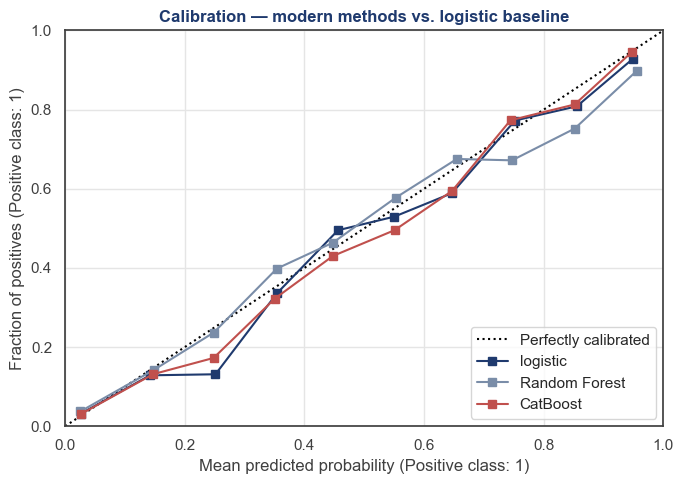

In [12]:
# A calibration curve plots predicted probability (x) against the observed
# frequency (y). A well-calibrated model hugs the diagonal.
fig, ax = plt.subplots(figsize=(7, 5))
CalibrationDisplay.from_predictions(y_test_c, p_logreg, n_bins=10,
                                    name="logistic", ax=ax, color=PRIMARY)
CalibrationDisplay.from_predictions(y_test_c, p_rf, n_bins=10,
                                    name="Random Forest", ax=ax, color="#7A8DA8")
CalibrationDisplay.from_predictions(y_test_c, p_cb, n_bins=10,
                                    name="CatBoost", ax=ax, color=ACCENT_RED)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("Calibration — modern methods vs. logistic baseline")
fig.tight_layout()
plt.show()


**Reading the calibration.** All three curves track the diagonal far better than the deep single tree did in Section 1 — bagging and boosting both **cured the miscalibration** that ruined the single tree's probabilities. That is the real pay-off of the ensembles: they deliver *believable* probabilities, and on this dataset CatBoost even nudges past the logistic baseline on log-loss. In an actuarial workflow that pipes the probability into a downstream price or reserve calculation, calibration is non-negotiable.


## 3. Feed-forward neural network on car-insurance claims

A feed-forward neural network is a stack of dense layers, each applying a linear transform followed by a non-linear activation, fit by gradient descent on the log-loss. We use scikit-learn's `MLPClassifier` here so the API stays consistent with the rest of the notebook.

> **Note.** Neural networks on tabular data rarely outperform gradient boosting in practice; we run one mainly as a connection to the deep-learning toolkit that the later sections of the seminar lean on.


In [13]:
from sklearn.neural_network import MLPClassifier

# A small 2-hidden-layer network (64 then 32 units) with ReLU activations.
# early_stopping holds out part of the training data and stops when the
# validation score stops improving — the simplest guard against overfitting.
mlp = Pipeline([
    ("p", preprocess_cls),
    ("m", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=1e-3,
        alpha=1e-3,                # L2 weight decay (regularisation strength)
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=SEED,
    )),
]).fit(X_train_c, y_train_c)
p_mlp = mlp.predict_proba(X_test_c)[:, 1]
cls_metrics(y_test_c, p_mlp, "FFN (64, 32)").round(4)


,log_loss,AUC,F1,accuracy
"FFN (64, 32)",0.3465,0.9135,0.7657,0.847


**Reading the metrics.** The small two-layer MLP lands close to CatBoost and logistic on log-loss and AUC, and comfortably ahead of the Random Forest — but it does not reach the top of the table. On *strictly tabular* data with a moderate number of features, a feed-forward network has no structural advantage over a gradient-boosted ensemble. Neural networks earn their keep when the features get richer: text (token embeddings), images (convolutional networks), and sequences (recurrent networks / Transformers) — the territory the later sections of the seminar explore.


### Final scoreboard


In [14]:
comparison2 = pd.concat([
    cls_metrics(y_test_c, p_logreg, "logistic regression"),
    cls_metrics(y_test_c, p_rf,     "Random Forest"),
    cls_metrics(y_test_c, p_cb,     "CatBoost"),
    cls_metrics(y_test_c, p_mlp,    "FFN (64, 32)"),
])
comparison2.style.format({"log_loss": "{:.4f}", "AUC": "{:.3f}", "F1": "{:.3f}", "accuracy": "{:.3f}"})


,log_loss,AUC,F1,accuracy
logistic regression,0.3410,0.915,0.755,0.848
Random Forest,0.3954,0.895,0.721,0.827
CatBoost,0.3380,0.916,0.757,0.845
"FFN (64, 32)",0.3465,0.913,0.766,0.847


**Final scoreboard.** **CatBoost takes the top spot** — the best log-loss and a hair ahead on AUC — but the real headline is how *little* separates it from a plain logistic regression: the two are essentially tied, with the neural networks just behind and the Random Forest clearly last. The car-insurance signal is largely linear, so the simple model is almost as good as the best. The pattern worth internalising: **start with the simple, interpretable model; reach for gradient boosting as the default non-linear challenger** (here it just edges ahead); **and bring in a neural network only when the features go beyond a flat table** (text, images, sequences). Fancy models do not automatically win — and when they do, the margin may be too small to matter.


## 4. Agglomerative hierarchical clustering on the car-insurance portfolio

Agglomerative hierarchical clustering starts with every observation as its own cluster, then iteratively merges the two closest clusters until a single cluster remains. The full merge history forms a **dendrogram** — arguably the most interpretable single artefact in clustering analysis.

Two structural advantages over k-means (Section 1's clustering method):

- **No need to pick K up front** — the dendrogram shows every partition from 1 to n clusters at once, and you choose where to *cut* it after seeing the tree.
- **Captures non-spherical, nested cluster shapes** — k-means assumes roughly spherical clusters of similar size; agglomerative clustering makes no such assumption.

The trade-off is computational: agglomerative clustering costs $O(n^2)$ in time and memory, so we sub-sample the 10,000-policy portfolio down to 2,000 rows for the demo. K-means, by contrast, scales comfortably to the full dataset.


In [15]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

# Re-use the unsupervised pre-processing recipe from Section 1.
df_unsup = X_cls.copy()
cat_cols_u = [c for c in df_unsup.columns if df_unsup[c].dtype == "object" or c == "POSTAL_CODE"]
num_cols_u = [c for c in df_unsup.columns if c not in cat_cols_u]

preprocess_unsup = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler())]),               num_cols_u),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols_u),
])
X_scaled = preprocess_unsup.fit_transform(df_unsup)

# Sub-sample for the dendrogram (otherwise plot is unreadable, runtime is long).
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(X_scaled.shape[0], size=2_000, replace=False)
X_sample = X_scaled[sample_idx]
print(f"Sub-sample for hierarchical clustering: {X_sample.shape}")


Sub-sample for hierarchical clustering: (2000, 35)


### The dendrogram with Ward's linkage

Ward's linkage merges the pair of clusters that minimises the *increase* in within-cluster variance — the same criterion k-means optimises on the full dataset. It tends to produce balanced, compact clusters and is the recommended default for actuarial portfolio segmentation.


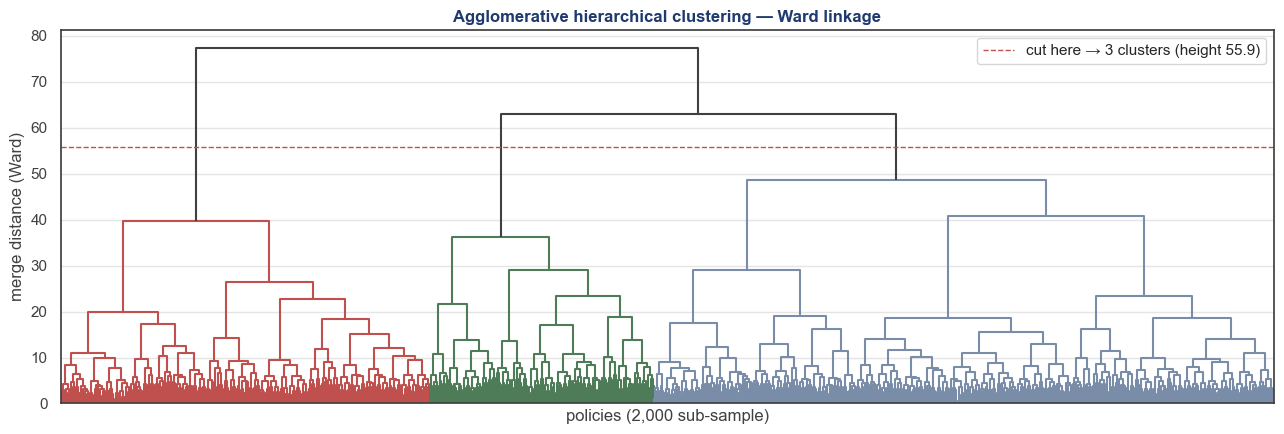

In [16]:
# Compute the full merge hierarchy with Ward linkage (minimises the increase in
# within-cluster variance at each merge — the same objective k-means optimises).
Z = linkage(X_sample, method="ward")

# Cut into K = 3 clusters to match the k-means choice in Section 1. The cut
# height sits in the gap between the 3rd-last and 2nd-last merges.
K_CUT = 3
cut_height = (Z[-K_CUT, 2] + Z[-(K_CUT - 1), 2]) / 2

# Plot the dendrogram; the dashed line marks where we cut it into K_CUT clusters.
fig, ax = plt.subplots(figsize=(13, 4.5))
dendrogram(Z, no_labels=True, color_threshold=cut_height, ax=ax,
           above_threshold_color=GRAY_TEXT)
ax.axhline(cut_height, color=ACCENT_RED, ls="--", lw=1,
           label=f"cut here → {K_CUT} clusters (height {cut_height:.1f})")
ax.set_xlabel("policies (2,000 sub-sample)")
ax.set_ylabel("merge distance (Ward)")
ax.set_title("Agglomerative hierarchical clustering — Ward linkage")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()


**Reading the dendrogram.** Large vertical gaps between merges flag *natural* clusters (the merge would cost a lot of within-cluster variance, so the structure "resists" it). We cut at **K = 3** — matching the k-means choice in Section 1 — giving three clusters of uneven size (here roughly 1,020 / 610 / 370 policies). The next-largest gap would justify **K = 4** just as well (it mostly splits the biggest segment in two); the beauty of the dendrogram is that this choice is explicit and revisable *after* seeing the tree, unlike k-means where K is fixed up front.


### Cut the dendrogram at K = 3 — and compare to k-means

The dendrogram is a *hierarchy*, not a finished partition. To obtain concrete clusters we **cut** the tree at the height marked above, which yields three groups. A natural question follows: do these three agglomerative groups agree with the three groups k-means finds on the same data?

We answer it with a **cross-tabulation**. We run both algorithms on the same 2,000-policy sample, then count how many policies fall into each (agglomerative cluster, k-means cluster) pair. The cluster *labels* are arbitrary integers — "cluster 0" from one method has no reason to coincide with "cluster 0" from the other — so we read agreement as a **near-permutation pattern**: if each row has a single dominant column, the two methods carved the portfolio essentially the same way.


In [17]:
# Cut the dendrogram into 3 clusters; also run k-means with K=3 on the same sample.
agg = AgglomerativeClustering(n_clusters=3, linkage="ward").fit(X_sample)
km  = KMeans(n_clusters=3, n_init=10, random_state=SEED).fit(X_sample)

# Cross-tabulate the two labelings: how many policies share each (agg, km) pair.
agree = pd.crosstab(
    pd.Series(agg.labels_, name="agglomerative"),
    pd.Series(km.labels_,  name="k-means"),
)
agree


k-means,0,1,2
agglomerative,,,
0,97,249,676
1,32,475,101
2,298,2,70


**Reading the cross-tabulation.** Rows are agglomerative clusters; columns are k-means clusters. Each row concentrates most of its policies in one column, so the two methods agree on the bulk of policies (roughly seven in ten here) — the boundary cases are where they differ. The practical guidance: **use k-means** when you need to assign hundreds of thousands of policies quickly, and **use agglomerative clustering** when you want a defensible, inspectable choice of K on a moderately-sized portfolio.


### Cluster sizes and a narrative on the agglomerative clusters


In [18]:
sample_df = df_unsup.iloc[sample_idx].copy()
sample_df["agg_cluster"] = agg.labels_

centroid_num = sample_df.groupby("agg_cluster")[num_cols_u].mean().round(2)
centroid_cat = sample_df.groupby("agg_cluster")[cat_cols_u].agg(lambda s: s.mode().iloc[0])
centroid_agg = pd.concat([centroid_num, centroid_cat], axis=1)
centroid_agg["n_policies"] = sample_df.groupby("agg_cluster").size()
# Attach observed claim rate per cluster (using the held-out label only for narrative)
y_sample = y_cls.iloc[sample_idx].values
centroid_agg["obs_claim_rate"] = (
    pd.Series(y_sample, index=sample_df.index)
      .groupby(sample_df["agg_cluster"]).mean().round(3)
)
centroid_agg


,CREDIT_SCORE,VEHICLE_OWNERSHIP,MARRIED,CHILDREN,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,VEHICLE_YEAR,POSTAL_CODE,VEHICLE_TYPE,n_policies,obs_claim_rate
agg_cluster,,,,,,,,,,,,,,,,,,,
0,0.52,0.68,0.51,1.00,11194.38,1.05,0.09,0.70,26-39,female,majority,0-9y,high school,upper class,before 2015,10238,sedan,1022,0.299
1,0.47,0.60,0.25,0.01,13643.37,0.76,0.12,0.42,16-25,female,majority,0-9y,high school,poverty,before 2015,10238,sedan,608,0.502
2,0.58,0.85,0.77,0.95,10276.07,3.85,0.91,3.04,65+,male,majority,20-29y,university,upper class,before 2015,10238,sedan,370,0.057


**Turning the agglomerative clusters into actuarial narratives.** Each row is one cluster — read it like a one-line portfolio-segment description (`n_policies` is the segment size; `obs_claim_rate` is its claim frequency). The claim rate is the sanity check: even though the clustering **never saw the `OUTCOME` label**, the three segments span a claim frequency from roughly 6% to 50% — almost a ninefold spread. The lowest-risk segment is dominated by older (65+), highly experienced, vehicle-owning drivers; the middle segment by established 26–39-year-olds; the highest-risk segment by young (16–25), inexperienced, lower-income drivers. That mirrors the three-tier k-means segmentation from Section 1. That is the unsupervised payoff — a portfolio segmentation produced *without* labels, backed by a *dendrogram artefact* the actuary can show a stakeholder: "here is why we chose three clusters, and here is what would change if we cut at four."


## 5. Individual claims reserving

> **A hands-on walkthrough.** This section is longer than the exercises above because it follows a complete actuarial workflow end-to-end: simulate a claims portfolio, reserve it the classical way, reserve it with machine learning, and check which lands closer to the truth. It reproduces — in spirit — Mario Wüthrich's landmark paper *Machine learning in individual claims reserving* (Scandinavian Actuarial Journal, 2018).

**Why reserve at the level of the individual claim?** *Claims reserving* means estimating the money an insurer still owes on claims that have already happened but are not yet fully paid. Traditionally this is done on *aggregate* data: every claim is summed into a development **triangle** (accident year × development year) and a method such as **chain-ladder** projects the missing lower-right half. This is simple and battle-tested — but a triangle cell is just a total. It cannot tell whether those payments came from many small, fast-closing claims or from a few large, lawyer-driven ones.

**What Wüthrich proposed.** Keep every claim as its own row, together with its features — claim code, diagnosis, whether a lawyer is involved, reporting delay, payments made so far — and let a machine-learning model learn how such claims *develop*. The portfolio reserve becomes the sum of individual predictions. Wüthrich deliberately kept the illustration minimal: he modelled only the **number of payments** (not their size) and used only a single **regression tree**, while noting that random forests and boosting are the natural robust upgrades. We follow exactly that arc.

**What you will build.** (1) A synthetic portfolio of tens of thousands of individual claims whose structure mirrors the simulation machine behind the paper; (2) a classical chain-ladder reserve; (3) the paper's per-period regression tree; (4) a robustified individual-claim model (Random Forest + CatBoost) for the **number of payments** *and*, as the paper's compound-model extension, the **claim amount**; (5) an honest scorecard against the **true** reserve — which, because we simulated the data, we actually know; and (6) a SHAP read-out connecting the model back to actuarial intuition.

**The punchline up front.** On this portfolio, chain-ladder *over-reserves by roughly a third*, because the most recent accident years are dominated by claims that pay once and close quickly — a pattern the triangle wrongly projects forward. The individual models, which can *see* that a claim has already closed, land within a few percent of the truth. That is Wüthrich's point, made measurable.

### The data-generating process

The original paper uses a proprietary, fully-calibrated Swiss liability portfolio produced by the *individual claims history simulation machine* of Gabrielli–Wüthrich. That dataset is not redistributed, so we generate our own synthetic portfolio in Python with the **same column structure and roles**. Each row is one claim with the paper's covariates:

| our column | paper symbol | meaning |
|---|---|---|
| `AY` | $i$ | accident year (1 … 12) |
| `RepDel` | $j$ | reporting delay in years |
| `cc` | claim code | type of claim (11 categories, one dominant) |
| `diag` | diagnosis code | type of injury (25 categories) |
| `law` | lawyer involved | 1 if a lawyer is on the file (~25 %) |
| `Pay…`/`close_age` | $Y_{i,j\mid k}$, $Z$ | per-period payment & closing indicators |

For every claim we simulate the **entire** development over post-reporting periods $k = 0, 1, \dots$: at each period an open claim may make a payment (with a probability that depends on `cc`, `diag`, `law` and the development age) and may close (lawyer-involved claims stay open longer). Because we simulate the full square, we know each claim's complete future — the **answer key** against which every method will later be scored.

The **valuation date** is the end of accident year $I = 12$. A development cell is *observed* only if its calendar year $i + j + k \le I$; everything later is the future we must reserve for. A claim still open at valuation is a **reported-but-not-settled (RBNS)** claim; a claim already closed needs no reserve. All randomness is seeded for reproducibility.

In [2]:
# Reproducible generator, independent of the global NumPy seed set in the Setup cell.
rng = np.random.default_rng(SEED)

# Portfolio dimensions.
I_ACC  = 12        # accident years 1..I_ACC
J_MAX  = 3         # maximum reporting delay (years)
K_MAX  = 8         # maximum post-reporting development period (0..K_MAX); all claims close by then
N_RAW  = 90_000    # claims simulated before keeping the reported ones

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# --- static covariates (names & roles mirror Wuethrich's feature space) ---
cc_levels = np.arange(1, 12)                                       # claim code: 11 categories
cc_probs  = np.array([3, 4, 5, 4, 6, 5, 4, 3, 55, 6, 5], float); cc_probs /= cc_probs.sum()
cc = rng.choice(cc_levels, size=N_RAW, p=cc_probs)                 # one dominant code, as in the paper

diag_levels = np.arange(1, 26)                                     # diagnosis code: 25 categories
diag_probs  = np.linspace(3, 1, 25) ** 2
diag_probs[0] = 18; diag_probs[20] = 22                           # two dominant diagnoses
diag_probs /= diag_probs.sum()
diag = rng.choice(diag_levels, size=N_RAW, p=diag_probs)

law = (rng.random(N_RAW) < 0.25).astype(int)                      # lawyer involved (~25%)

ay_probs = np.linspace(0.8, 1.2, I_ACC); ay_probs /= ay_probs.sum()
acc_year  = rng.choice(np.arange(1, I_ACC + 1), size=N_RAW, p=ay_probs)
rep_delay = rng.choice(np.arange(0, J_MAX + 1), size=N_RAW, p=[0.72, 0.20, 0.06, 0.02])

# --- how features drive development (fixed, deterministic effects) ---
a_cc   = np.linspace(-0.9, 1.0, 11)      # claim code -> payment propensity
a_diag = np.linspace(-0.7, 0.8, 25)      # diagnosis  -> payment propensity
s_cc   = np.linspace(-0.5, 0.8, 11)      # claim code -> severity
s_diag = np.linspace(-0.4, 0.7, 25)      # diagnosis  -> severity
c_cc   = np.linspace(0.5, -0.6, 11)      # claim code -> closing speed
cc_idx, diag_idx = cc - 1, diag - 1

# --- simulate the full development square, period by period (vectorised) ---
pay_mat   = np.zeros((N_RAW, K_MAX + 1), dtype=int)     # 1 if a payment falls in period k
amt_mat   = np.zeros((N_RAW, K_MAX + 1), dtype=float)   # size of that payment
open_now  = np.ones(N_RAW, dtype=bool)                  # every claim is open at reporting
close_age = np.full(N_RAW, K_MAX, dtype=int)            # post-reporting period of closure

for k in range(K_MAX + 1):
    # payment indicator: more likely early, for high-cc/diag claims, and when a lawyer is involved
    p_pay = sigmoid(0.5 + a_cc[cc_idx] + a_diag[diag_idx] + 0.7 * law - 0.45 * k)
    pays  = open_now & (rng.random(N_RAW) < p_pay)
    pay_mat[pays, k] = 1
    mu = 7.6 + s_cc[cc_idx] + s_diag[diag_idx] + 0.05 * k          # log-severity of a payment
    amt_mat[pays, k] = rng.lognormal(mean=mu[pays], sigma=0.7)
    # closing hazard: rises with development age, but lawyers keep claims open longer
    if k < K_MAX:
        p_close = sigmoid(-1.0 + 0.55 * k - 1.3 * law + c_cc[cc_idx])
        closes  = open_now & (rng.random(N_RAW) < p_close)
    else:
        closes  = open_now.copy()                                  # force-close at the last period
    close_age[closes] = k
    open_now = open_now & ~closes                                  # closed claims drop out next period

# --- assemble one row per claim ---
claims_all = pd.DataFrame({
    "ClNr": np.arange(N_RAW), "AY": acc_year, "cc": cc, "diag": diag,
    "law": law, "RepDel": rep_delay, "close_age": close_age,
    "n_pay_total": pay_mat.sum(axis=1), "amt_total": amt_mat.sum(axis=1),
})

# keep only claims reported by the valuation date t = I_ACC  (AY + RepDel <= I_ACC)
reported  = (claims_all["AY"] + claims_all["RepDel"] <= I_ACC).values
df_claims = claims_all[reported].reset_index(drop=True)
pay_dev   = pay_mat[reported]       # payment-indicator matrix for the reported claims
amt_dev   = amt_mat[reported]       # payment-amount    matrix for the reported claims

# --- split each claim's development into "observed" and "future" at the valuation date ---
AY = df_claims["AY"].values
J  = df_claims["RepDel"].values
a_obs = I_ACC - AY - J                            # last post-reporting period observed (>= 0)
k_grid   = np.arange(K_MAX + 1)[None, :]
obs_mask = k_grid <= a_obs[:, None]               # development cells seen by the valuation date
fut_mask = ~obs_mask

n_pay_obs = (pay_dev * obs_mask).sum(axis=1)      # payments counted so far
amt_obs   = (amt_dev * obs_mask).sum(axis=1)
n_pay_fut = (pay_dev * fut_mask).sum(axis=1)      # TRUE future number of payments (the answer key)
amt_fut   = (amt_dev * fut_mask).sum(axis=1)      # TRUE future amount

cl_now  = (df_claims["close_age"].values <= a_obs).astype(int)    # 1 = already closed at valuation
ell_now = I_ACC - AY                                              # development lag now
is_rbns = (cl_now == 0)                                           # open = reported-but-not-settled
settled = (df_claims["close_age"].values <= a_obs)               # fully observed -> usable for training

df_claims["a_obs"], df_claims["ell_now"], df_claims["cl_now"] = a_obs, ell_now, cl_now
df_claims["n_pay_obs"], df_claims["amt_obs"] = n_pay_obs, amt_obs

# --- shared design-matrix builder (used by every model below) ---
CC_CATS, DIAG_CATS = list(range(1, 12)), list(range(1, 26))

def make_design(cc_a, diag_a, law_a, repdel_a, ell_a, cl_a, npay_a, amt_a):
    """Turn raw claim state into the numeric design matrix the models consume."""
    base = pd.DataFrame({
        "RepDel": repdel_a, "ell": ell_a, "cl": cl_a,
        "n_pay_through": npay_a, "amt_through": amt_a, "law": law_a,
    })
    cc_d   = pd.get_dummies(pd.Categorical(cc_a,   categories=CC_CATS),   prefix="cc")
    diag_d = pd.get_dummies(pd.Categorical(diag_a, categories=DIAG_CATS), prefix="diag")
    return pd.concat([base, cc_d.reset_index(drop=True), diag_d.reset_index(drop=True)], axis=1)

print(f"Simulated {N_RAW:,} claims; {len(df_claims):,} reported by valuation "
      f"(RBNS/open: {is_rbns.sum():,}, closed: {(~is_rbns).sum():,}).")
print(f"TRUE future reserve  ->  payments: {n_pay_fut.sum():,.0f}   amount: CHF {amt_fut.sum():,.0f}")
df_claims[["AY", "cc", "diag", "law", "RepDel", "ell_now", "cl_now", "n_pay_obs", "n_pay_total"]].head()

Simulated 90,000 claims; 86,659 reported by valuation (RBNS/open: 18,238, closed: 68,421).
TRUE future reserve  ->  payments: 18,865   amount: CHF 107,040,947


,AY,cc,diag,law,RepDel,ell_now,cl_now,n_pay_obs,n_pay_total
0,12,9,11,1,0,0,0,1,3
1,2,9,1,0,0,10,1,1,1
2,6,9,17,0,0,6,1,2,2
3,9,9,4,0,0,3,0,3,3
4,3,3,21,0,0,9,1,1,1


### Exploring the portfolio

Before modelling, a few pictures of how the portfolio behaves. We look at the **average development pattern** (how payment activity fades as claims mature), the **reporting-delay** distribution, the skewed **claim-code** marginal (the paper's Figure 4 shows the same one-category-dominates shape), and the single most important behavioural driver: **claims with a lawyer involved generate more payments**, because they stay open longer. Keep that last panel in mind — it reappears in both the regression tree and the SHAP plot.

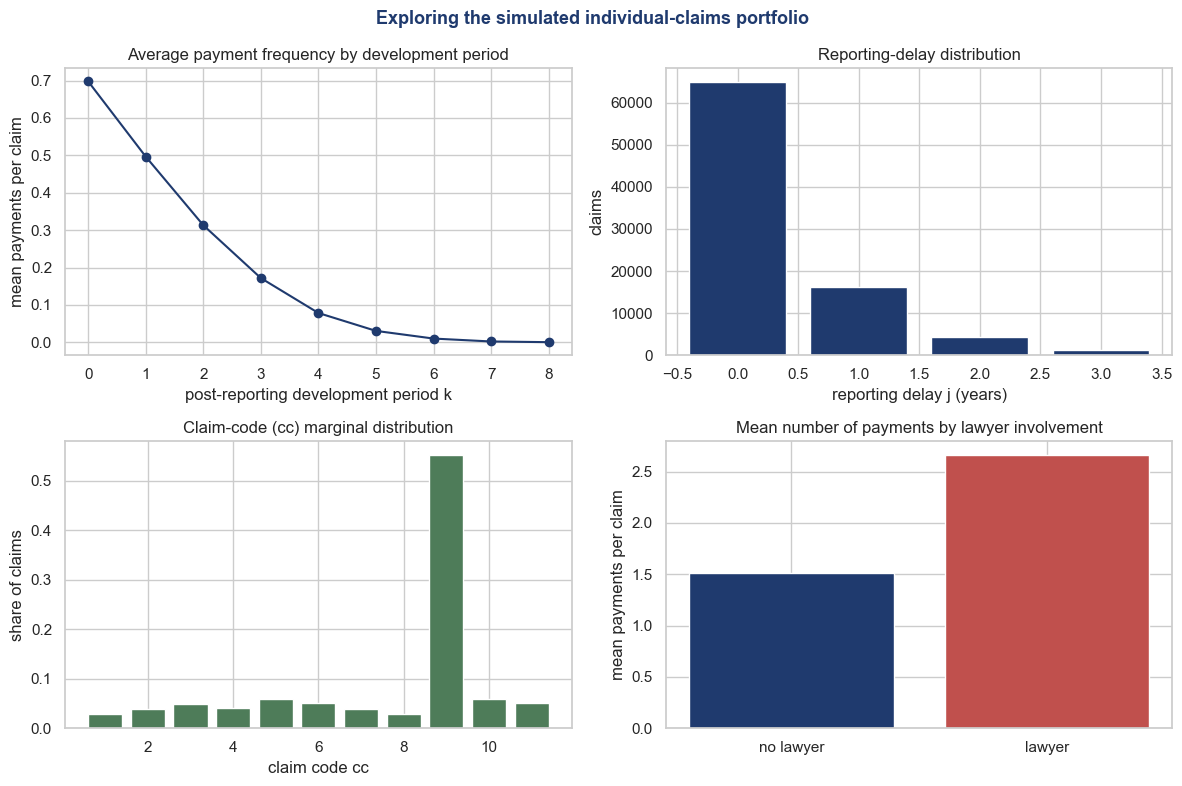

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# (a) average development pattern: payment frequency by post-reporting period
dev_pattern = [pay_dev[:, k].sum() / len(df_claims) for k in range(K_MAX + 1)]
ax[0, 0].plot(range(K_MAX + 1), dev_pattern, marker="o", color=PRIMARY)
ax[0, 0].set(title="Average payment frequency by development period",
             xlabel="post-reporting development period k", ylabel="mean payments per claim")

# (b) reporting-delay distribution
rd = df_claims["RepDel"].value_counts().sort_index()
ax[0, 1].bar(rd.index, rd.values, color=PRIMARY)
ax[0, 1].set(title="Reporting-delay distribution", xlabel="reporting delay j (years)", ylabel="claims")

# (c) claim-code marginal (echoes the paper's Figure 4)
ccm = df_claims["cc"].value_counts(normalize=True).sort_index()
ax[1, 0].bar(ccm.index, ccm.values, color=ACCENT_GREEN)
ax[1, 0].set(title="Claim-code (cc) marginal distribution", xlabel="claim code cc", ylabel="share of claims")

# (d) lawyer involvement lengthens the claim
law_dev = df_claims.groupby("law")["n_pay_total"].mean()
ax[1, 1].bar(["no lawyer", "lawyer"], law_dev.values, color=[PRIMARY, ACCENT_RED])
ax[1, 1].set(title="Mean number of payments by lawyer involvement", ylabel="mean payments per claim")

fig.suptitle("Exploring the simulated individual-claims portfolio", fontsize=13,
             color=PRIMARY, fontweight="bold")
fig.tight_layout()
plt.show()

### The classical benchmark: chain-ladder

**Chain-ladder** is the workhorse of reserving. It aggregates the individual payments into a cumulative triangle indexed by accident year (rows) and development lag $\ell = j + k$ (columns), where only the upper-left half — calendar year $i + \ell \le I$ — is observed. It then assumes that *every accident year develops in the same proportions*: from the observed cells it estimates **age-to-age factors** $f_\ell$ (how much the cumulative total grows from lag $\ell$ to $\ell+1$, volume-weighted across accident years) and multiplies the latest diagonal forward to ultimate. The reserve is ultimate minus paid-to-date.

Its strength is simplicity; its blind spot is that **it discards every individual feature**. A cell is a sum — chain-ladder cannot know that a recent accident year's high early payment count comes mostly from claims that have *already closed* and will not pay again. As Wüthrich faithfully reproduces it, we apply chain-ladder directly to the **number-of-payments** triangle, and (for the amount extension) to the paid-amount triangle.

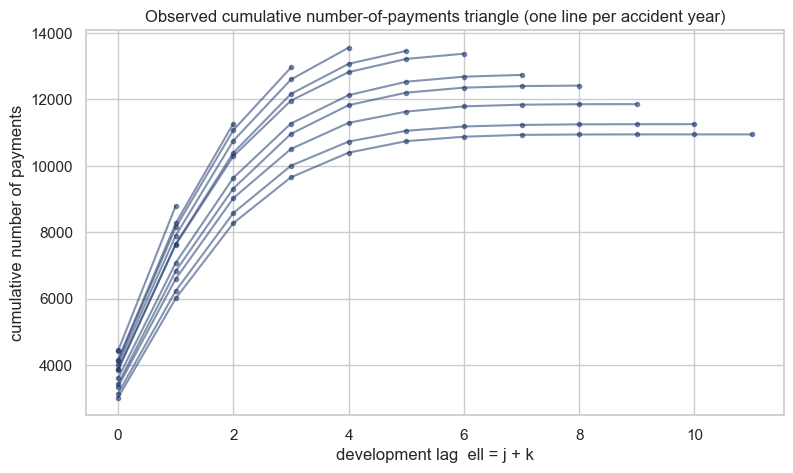

Chain-ladder count reserve :       24,769   (true 18,865,  +31.3%)
Chain-ladder amount reserve:  135,555,487   (true 107,040,947,  +26.6%)


In [4]:
D = J_MAX + K_MAX + 1                         # number of development lags ell = 0..D-1
ay_rows = AY - 1                             # 0-based accident-year index per claim

def build_triangle(value_mat):
    """Aggregate per-claim development into an accident-year x development-lag triangle.
    A payment in post-reporting period k falls in development lag ell = RepDel + k."""
    inc = np.zeros((I_ACC, D))
    for k in range(K_MAX + 1):
        lag = J + k
        np.add.at(inc, (ay_rows, lag), value_mat[:, k])
    return inc

# a triangle cell (accident year i, lag ell) is observed iff i + ell <= I_ACC
ay_grid    = (np.arange(I_ACC) + 1)[:, None]
lag_grid   = np.arange(D)[None, :]
observable = (ay_grid + lag_grid) <= I_ACC

def chain_ladder(inc):
    """Classical volume-weighted (Mack) chain-ladder on an incremental triangle.
    Returns ultimate, latest-observed and reserve per accident year, plus the link ratios."""
    cum = np.cumsum(np.where(observable, inc, 0.0), axis=1)
    f = np.ones(D - 1)
    for l in range(D - 1):
        sel = observable[:, l + 1]                       # accident years with column l+1 observed
        den, num = cum[sel, l].sum(), cum[sel, l + 1].sum()
        f[l] = num / den if den > 0 else 1.0             # age-to-age development factor
    full = cum.astype(float).copy()
    last_obs = observable.sum(axis=1) - 1                # latest observed lag per accident year
    for i in range(I_ACC):
        for l in range(last_obs[i], D - 1):
            full[i, l + 1] = full[i, l] * f[l]           # project the lower-right triangle
    ultimate = full[:, -1]
    latest   = cum[np.arange(I_ACC), last_obs]
    return ultimate, latest, ultimate - latest, f

inc_cnt = build_triangle(pay_dev)
inc_amt = build_triangle(amt_dev)
ult_cnt, lat_cnt, res_cnt_cl, f_cnt = chain_ladder(inc_cnt)
ult_amt, lat_amt, res_amt_cl, f_amt = chain_ladder(inc_amt)

# the TRUE future per accident year (known because we simulated the full square)
true_cnt_ay = np.array([n_pay_fut[ay_rows == i].sum() for i in range(I_ACC)])
true_amt_ay = np.array([amt_fut[ay_rows == i].sum() for i in range(I_ACC)])

# visualise the observed cumulative count triangle
cum_cnt = np.cumsum(np.where(observable, inc_cnt, np.nan), axis=1)
fig, ax = plt.subplots(figsize=(9, 5))
for i in range(I_ACC):
    ax.plot(range(D), cum_cnt[i], marker=".", color=PRIMARY, alpha=0.55)
ax.set(title="Observed cumulative number-of-payments triangle (one line per accident year)",
       xlabel="development lag  ell = j + k", ylabel="cumulative number of payments")
plt.show()

print(f"Chain-ladder count reserve : {res_cnt_cl.sum():>12,.0f}   "
      f"(true {n_pay_fut.sum():,.0f},  {100 * (res_cnt_cl.sum() / n_pay_fut.sum() - 1):+.1f}%)")
print(f"Chain-ladder amount reserve: {res_amt_cl.sum():>12,.0f}   "
      f"(true {amt_fut.sum():,.0f},  {100 * (res_amt_cl.sum() / amt_fut.sum() - 1):+.1f}%)")

### Wüthrich's model: a regression tree for the (Y, Z) transition

Here is the paper's actual method. Each claim develops as a sequence of two binary indicators per period: $Y$ — *did a payment occur?* — and $Z$ — *did the claim close?* Wüthrich combines them into a single four-valued response $YZ = Y + 2Z \in \{0,1,2,3\}$ and fits a **classification tree** (the CART algorithm, Gini impurity) that predicts the *next* period's $(Y, Z)$ from the claim's current state: its `cc`, `diag`, `law`, reporting delay, current open/closed status, and payment history.

A tree is grown large and then **pruned** back by cost-complexity — we grow it, read off the candidate penalties, and pick the one that cross-validates best (the paper uses the closely-related one-standard-error rule). The cell below reproduces this for development lag $\ell = 1$, the same lag the paper plots in its Figure 3.

Read the resulting tree top-down: the **very first split is on `law`** — exactly the paper's headline. Claims *with* a lawyer (right branch) land in leaves dominated by class "Y1 Z0" (pays, stays open); claims *without* one close sooner. The single tree is illustrative and a little unstable — which is precisely why, next, we robustify it.

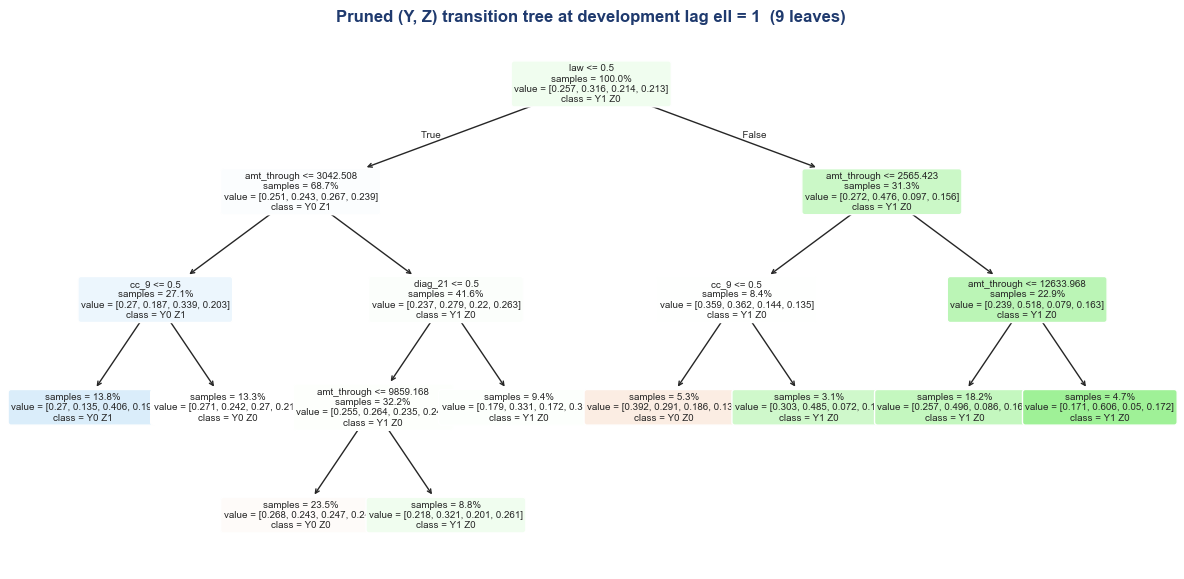

pruned tree: 9 leaves, ccp_alpha = 0.00065, test accuracy = 0.362


In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score

ca = df_claims["close_age"].values
A_DEMO = 1                                          # current period; we predict period A_DEMO + 1

# training rows: settled claims still OPEN at the start of period A_DEMO + 1 (a transition exists)
trans_sel = settled & (ca >= A_DEMO + 1)
# joint response  YZ = Y_{a+1} + 2 Z_{a+1}  in {0,1,2,3}, exactly as in Wuethrich (2018)
yz_next = pay_dev[:, A_DEMO + 1] + 2 * (ca == A_DEMO + 1).astype(int)

X_cart = make_design(df_claims["cc"].values[trans_sel], df_claims["diag"].values[trans_sel],
                     df_claims["law"].values[trans_sel], J[trans_sel],
                     J[trans_sel] + A_DEMO, np.zeros(trans_sel.sum(), int),
                     pay_dev[:, :A_DEMO + 1].sum(axis=1)[trans_sel],
                     amt_dev[:, :A_DEMO + 1].sum(axis=1)[trans_sel])
y_cart = yz_next[trans_sel]

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_cart, y_cart, test_size=0.25, random_state=SEED)

# grow a large tree, then prune by cost-complexity, choosing the penalty by cross-validation
big_tree = DecisionTreeClassifier(random_state=SEED).fit(Xc_tr, yc_tr)
ccp_path = big_tree.cost_complexity_pruning_path(Xc_tr, yc_tr)
alphas   = ccp_path.ccp_alphas[::max(1, len(ccp_path.ccp_alphas) // 20)]
cv_score = [cross_val_score(DecisionTreeClassifier(ccp_alpha=a, random_state=SEED),
                            Xc_tr, yc_tr, cv=3).mean() for a in alphas]
best_alpha = alphas[int(np.argmax(cv_score))]
cart = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=SEED).fit(Xc_tr, yc_tr)

fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(cart, feature_names=list(X_cart.columns),
          class_names=["Y0 Z0", "Y1 Z0", "Y0 Z1", "Y1 Z1"],
          filled=True, rounded=True, proportion=True, impurity=False, fontsize=7, ax=ax)
ax.set_title(f"Pruned (Y, Z) transition tree at development lag ell = 1  "
             f"({cart.get_n_leaves()} leaves)", color=PRIMARY, fontweight="bold")
plt.show()

print(f"pruned tree: {cart.get_n_leaves()} leaves, ccp_alpha = {best_alpha:.5f}, "
      f"test accuracy = {cart.score(Xc_te, yc_te):.3f}")

### Robustifying the tree: Random Forest and CatBoost

A single tree is easy to read but jumps around when the data change slightly. The paper's own outlook recommends the fix used everywhere in modern ML: **ensembles** — Random Forests (average many de-correlated trees) and **gradient boosting** (CatBoost here; add small trees that each correct the running error). Both are ideal for this heterogeneous, mixed categorical/numeric claims data.

Rather than chaining per-period transitions, we now predict directly, at the claim level: **given a claim's state today, how many more payments will it make?** The training set is built the way a practitioner builds it from history — take every **settled** claim (one whose development we have fully observed) and snapshot it at each development age it passed through, recording the state then and the payments that *still followed*. The model learns the map *state → future development*, which we then apply to the open (RBNS) claims at the valuation date.

We tune CatBoost's depth and learning rate with a small cross-validated search, then report each model's accuracy on a held-out slice of snapshots. Target (a) is the paper's **number of payments**.

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor

# Training set: snapshot every SETTLED claim at each development age it passed through, recording
# the claim's state then and how many payments / how much money still followed.
snap = {k: [] for k in ["cc", "diag", "law", "RepDel", "ell", "cl", "npay", "amt", "fcnt", "famt"]}
for a in range(K_MAX + 1):
    sel = settled & (ca >= a)                          # claims that reached development age a
    if not sel.any():
        continue
    npay_through = pay_dev[:, :a + 1].sum(axis=1)
    amt_through  = amt_dev[:, :a + 1].sum(axis=1)
    fcnt = pay_dev[:, a + 1:].sum(axis=1)              # payments still to come after age a
    famt = amt_dev[:, a + 1:].sum(axis=1)
    cl_a = (ca <= a).astype(int)
    snap["cc"].append(df_claims["cc"].values[sel]);     snap["diag"].append(df_claims["diag"].values[sel])
    snap["law"].append(df_claims["law"].values[sel]);   snap["RepDel"].append(J[sel])
    snap["ell"].append(J[sel] + a);                     snap["cl"].append(cl_a[sel])
    snap["npay"].append(npay_through[sel]);             snap["amt"].append(amt_through[sel])
    snap["fcnt"].append(fcnt[sel]);                     snap["famt"].append(famt[sel])
snap = {k: np.concatenate(v) for k, v in snap.items()}

X_snap = make_design(snap["cc"], snap["diag"], snap["law"], snap["RepDel"],
                     snap["ell"], snap["cl"], snap["npay"], snap["amt"])
y_cnt = snap["fcnt"].astype(float)        # target (a): number of future payments
y_amt = snap["famt"].astype(float)        # target (b): future amount (used in the next cell)

# keep the training set brisk on a laptop
if len(X_snap) > 100_000:
    keep   = rng.choice(len(X_snap), 100_000, replace=False)
    X_snap = X_snap.iloc[keep].reset_index(drop=True)
    y_cnt, y_amt = y_cnt[keep], y_amt[keep]

Xtr, Xte, ycnt_tr, ycnt_te, yamt_tr, yamt_te = train_test_split(
    X_snap, y_cnt, y_amt, test_size=0.25, random_state=SEED)

# light cross-validated hyperparameter search for CatBoost (on a subsample, for speed)
sub = rng.choice(len(Xtr), min(30_000, len(Xtr)), replace=False)
search = RandomizedSearchCV(
    CatBoostRegressor(iterations=150, random_seed=SEED, verbose=0),
    {"depth": [4, 6, 8], "learning_rate": [0.03, 0.05, 0.1]},
    n_iter=4, cv=3, scoring="neg_root_mean_squared_error", random_state=SEED, n_jobs=-1,
).fit(Xtr.iloc[sub], ycnt_tr[sub])
best = search.best_params_

# fit the two count models
rf_cnt = RandomForestRegressor(n_estimators=150, min_samples_leaf=20,
                               n_jobs=-1, random_state=SEED).fit(Xtr, ycnt_tr)
cb_cnt = CatBoostRegressor(iterations=350, random_seed=SEED, verbose=0, **best).fit(Xtr, ycnt_tr)

print("CatBoost hyperparameters chosen by cross-validation:", best)
pd.concat([
    metrics(ycnt_te, rf_cnt.predict(Xte), "Random Forest"),
    metrics(ycnt_te, cb_cnt.predict(Xte), "CatBoost"),
]).round(3)

CatBoost hyperparameters chosen by cross-validation: {'learning_rate': 0.1, 'depth': 6}


,RMSE,MAE,R²
Random Forest,0.653,0.412,0.454
CatBoost,0.636,0.405,0.481


### From counts to francs: the compound-model extension

Wüthrich's toy example stops at the number of payments; his Section 5 outlook describes the natural next step — a **compound model** that also predicts the *amount* of each payment, so the output is a reserve in money. We take that step here simply by re-fitting the *same* pipeline to a money target: each claim's **future paid amount**. (A payment count drives *how often* a claim pays; the severity model turns that into *how much*.)

We then produce the actual reserve. For every **open (RBNS)** claim we feed its valuation-date state to the models and sum the predictions across the portfolio. We also compute a deliberately naive **homogeneous** baseline — the paper's "no-feature" model — which predicts a claim's future from its development lag *alone*, ignoring `cc`, `diag` and `law`. The table contrasts all methods against the true reserve.

In [7]:
# target (b): the compound-model extension -- predict the future AMOUNT, not just the count
rf_amt = RandomForestRegressor(n_estimators=150, min_samples_leaf=20,
                               n_jobs=-1, random_state=SEED).fit(Xtr, yamt_tr)
cb_amt = CatBoostRegressor(iterations=350, random_seed=SEED, verbose=0, **best).fit(Xtr, yamt_tr)

# predict the reserve for the OPEN (RBNS) claims from their state at the valuation date
open_idx = np.where(is_rbns)[0]
X_open = make_design(df_claims["cc"].values[open_idx], df_claims["diag"].values[open_idx],
                     df_claims["law"].values[open_idx], J[open_idx], ell_now[open_idx],
                     np.zeros(len(open_idx), int), n_pay_obs[open_idx], amt_obs[open_idx])

pred_cnt_rf = np.clip(rf_cnt.predict(X_open), 0, None)
pred_cnt_cb = np.clip(cb_cnt.predict(X_open), 0, None)
pred_amt_rf = np.clip(rf_amt.predict(X_open), 0, None)
pred_amt_cb = np.clip(cb_amt.predict(X_open), 0, None)

# "homogeneous" baseline: ignore individual features, use only the development lag (no-feature model)
open_snap = snap["cl"] == 0
homo = pd.DataFrame({"ell":  snap["ell"][open_snap],
                     "fcnt": snap["fcnt"][open_snap].astype(float),
                     "famt": snap["famt"][open_snap].astype(float)}).groupby("ell").mean()
homo_cnt = homo["fcnt"].reindex(ell_now[open_idx]).fillna(0).values
homo_amt = homo["famt"].reindex(ell_now[open_idx]).fillna(0).values

reserves = pd.DataFrame({
    "payments":     [n_pay_fut.sum(), res_cnt_cl.sum(), homo_cnt.sum(), pred_cnt_rf.sum(), pred_cnt_cb.sum()],
    "amount (CHF)": [amt_fut.sum(),   res_amt_cl.sum(), homo_amt.sum(), pred_amt_rf.sum(), pred_amt_cb.sum()],
}, index=["TRUE (simulated)", "Chain-ladder", "Homogeneous", "Random Forest", "CatBoost"])
reserves.style.format("{:,.0f}")

,payments,amount (CHF)
TRUE (simulated),"18,865","107,040,947"
Chain-ladder,"24,769","135,555,487"
Homogeneous,"17,237","96,366,431"
Random Forest,"17,807","99,644,972"
CatBoost,"17,814","100,054,074"


### Scoring the methods against the truth

Because we simulated the data, we can do what the paper could not: compare every method to the **true** reserve. We express each method as a reserve *per accident year* and score those twelve numbers against the truth with RMSE, MAE and $R^2$, plus the overall **bias** (signed error on the portfolio total).

The pattern is stark and matches Wüthrich exactly. **Chain-ladder over-reserves by about a third** — its error is concentrated in the youngest accident years, whose early diagonals are inflated by claims that pay once and close. Every individual-claim model corrects this by *conditioning on whether the claim is still open*. Both the homogeneous and the feature-based models beat chain-ladder dramatically on the total; the **feature** models (Random Forest, CatBoost) add a further edge — visible most clearly per claim, where their $R^2$ far exceeds the no-feature baseline. The small residual *under*-estimate of the ML models is the price of training only on already-settled claims (see Limitations).

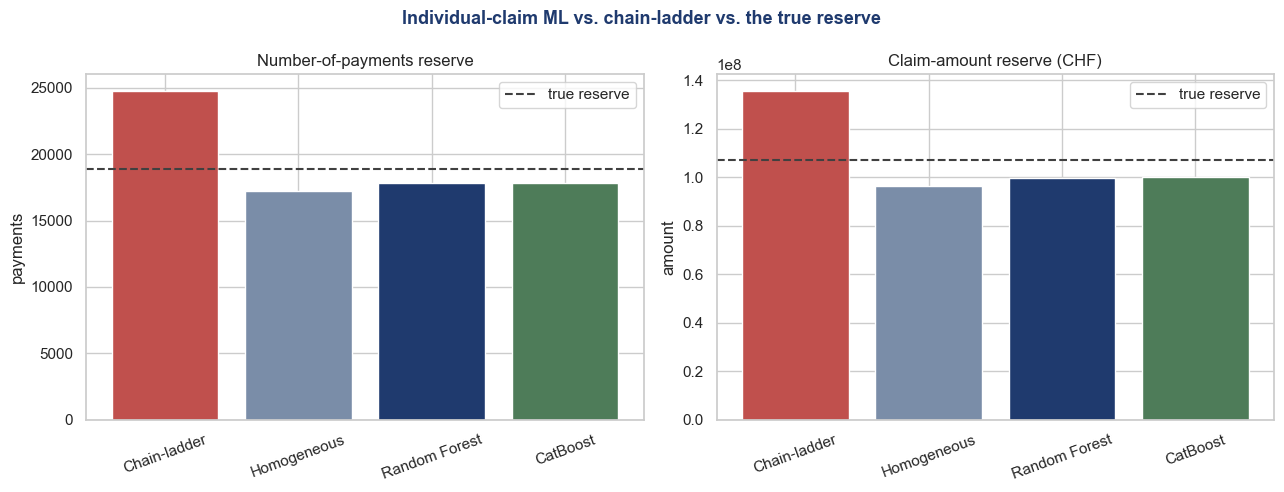

Per-accident-year reserve accuracy (number of payments):


,RMSE,MAE,R²,bias %
Chain-ladder,1298.3,497.9,0.705,31.3
Homogeneous,261.3,135.9,0.988,-8.6
Random Forest,177.9,91.7,0.994,-5.6
CatBoost,177.8,90.1,0.994,-5.6



Per-claim accuracy on the open (RBNS) claims -- this is where features beat the no-feature model:


,RMSE,MAE,R²
Homogeneous (lag only),0.980,0.735,0.066
Random Forest (features),0.856,0.666,0.288
CatBoost (features),0.836,0.645,0.320


In [8]:
# express each method as a reserve per accident year, then score it against the TRUE reserve
ay_open = AY[open_idx]
def by_ay(per_claim):
    return np.array([per_claim[ay_open == i + 1].sum() for i in range(I_ACC)])

score = pd.concat([
    metrics(true_cnt_ay, res_cnt_cl,         "Chain-ladder"),
    metrics(true_cnt_ay, by_ay(homo_cnt),    "Homogeneous"),
    metrics(true_cnt_ay, by_ay(pred_cnt_rf), "Random Forest"),
    metrics(true_cnt_ay, by_ay(pred_cnt_cb), "CatBoost"),
])
score["bias %"] = [100 * (res_cnt_cl.sum()  / n_pay_fut.sum() - 1),
                   100 * (homo_cnt.sum()    / n_pay_fut.sum() - 1),
                   100 * (pred_cnt_rf.sum() / n_pay_fut.sum() - 1),
                   100 * (pred_cnt_cb.sum() / n_pay_fut.sum() - 1)]

# also score the per-claim count prediction on the open claims (where features earn their keep)
true_open_cnt = n_pay_fut[open_idx].astype(float)
per_claim = pd.concat([
    metrics(true_open_cnt, homo_cnt,    "Homogeneous (lag only)"),
    metrics(true_open_cnt, pred_cnt_rf, "Random Forest (features)"),
    metrics(true_open_cnt, pred_cnt_cb, "CatBoost (features)"),
])

# bar chart: total reserve by method, against the true reserve, for both targets
methods = ["Chain-ladder", "Homogeneous", "Random Forest", "CatBoost"]
colors  = [ACCENT_RED, "#7A8DA8", PRIMARY, ACCENT_GREEN]
cnt_tot = [res_cnt_cl.sum(), homo_cnt.sum(), pred_cnt_rf.sum(), pred_cnt_cb.sum()]
amt_tot = [res_amt_cl.sum(), homo_amt.sum(), pred_amt_rf.sum(), pred_amt_cb.sum()]
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].bar(methods, cnt_tot, color=colors)
ax[0].axhline(n_pay_fut.sum(), color=GRAY_TEXT, ls="--", label="true reserve")
ax[0].set(title="Number-of-payments reserve", ylabel="payments"); ax[0].legend()
ax[0].tick_params(axis="x", rotation=20)
ax[1].bar(methods, amt_tot, color=colors)
ax[1].axhline(amt_fut.sum(), color=GRAY_TEXT, ls="--", label="true reserve")
ax[1].set(title="Claim-amount reserve (CHF)", ylabel="amount"); ax[1].legend()
ax[1].tick_params(axis="x", rotation=20)
fig.suptitle("Individual-claim ML vs. chain-ladder vs. the true reserve",
             fontsize=13, color=PRIMARY, fontweight="bold")
fig.tight_layout(); plt.show()

print("Per-accident-year reserve accuracy (number of payments):")
display(score.round({"RMSE": 1, "MAE": 1, "R²": 3, "bias %": 1}))
print("\nPer-claim accuracy on the open (RBNS) claims -- this is where features beat the no-feature model:")
display(per_claim.round(3))

### Opening the black box: SHAP

A reserve number is only trustworthy if we can explain *why* the model produced it. **SHAP values** decompose each individual prediction into additive contributions from each feature — how many francs of predicted reserve each feature pushed up or down, relative to the average claim. Averaged over many claims they give a global importance ranking; plotted per claim (the *beeswarm*) they show both *how much* and *in which direction* a feature matters (colour = the feature's value, high or low).

For an actuary the ranking should — and does — read as common sense:

- **`cl` (open vs. closed)** dominates: a claim already closed needs essentially no reserve.
- **`law` (lawyer involved)** pushes the reserve **up** — lawyer claims stay open and keep paying. This is the same signal the regression tree split on first, and the EDA panel showed.
- **`ell` (development maturity)**: the more developed a claim, the less future it has left.
- **`diag` / `cc`** shift the *severity* — certain injury and claim types are simply more expensive.

When a model's explanation matches actuarial intuition, you can defend it to a reviewer or regulator; when it does not, SHAP is how you catch it.

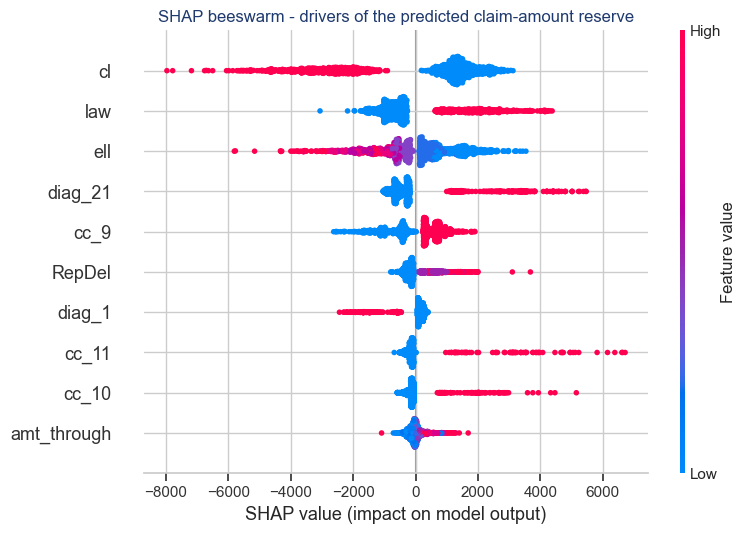

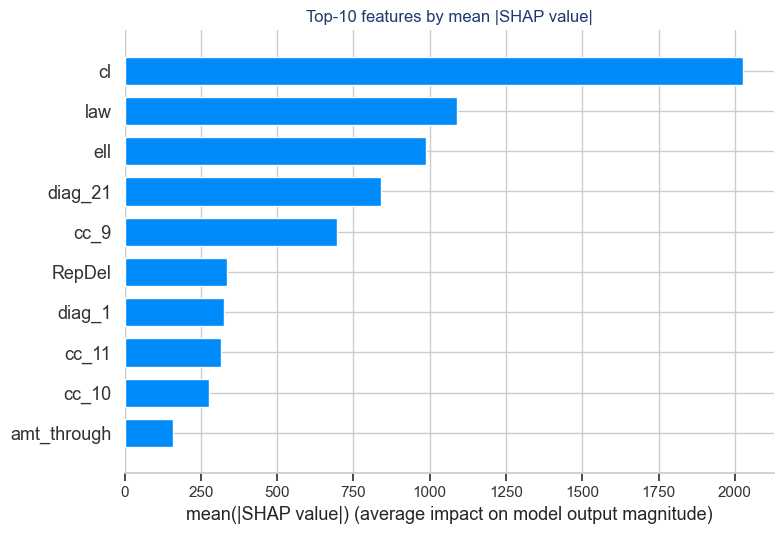

In [9]:
import shap

# explain the CatBoost AMOUNT model on a sample of held-out snapshots (varied maturities & states)
sample      = Xte.sample(min(1500, len(Xte)), random_state=SEED)
explainer   = shap.TreeExplainer(cb_amt)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, max_display=10, show=False)
plt.title("SHAP beeswarm - drivers of the predicted claim-amount reserve", color=PRIMARY)
plt.tight_layout(); plt.show()

shap.summary_plot(shap_values, sample, plot_type="bar", max_display=10, show=False)
plt.title("Top-10 features by mean |SHAP value|", color=PRIMARY)
plt.tight_layout(); plt.show()

### Limitations and where to go next

This is a deliberately clean illustration. Before anything like it reaches a financial statement, several caveats and extensions deserve attention.

- **Model risk and validation.** A reserve drives the balance sheet, so an ML reserving model needs the full governance treatment: out-of-time back-testing (does it hold up on a genuinely future calendar period?), stability monitoring, challenger models, and documentation a reviewer or regulator can follow. The chain-ladder remains an indispensable sanity check, not a discarded relic.
- **The maturity / labelling bias.** We trained only on **settled** claims, because those are the ones whose full development we have observed. But settled claims skew toward the small and fast — so the model slightly *under*-reserves the youngest, largest, still-open claims (the residual −5–7 % bias above). Real implementations correct this with development-period reweighting, separate large-loss models, or semi-supervised use of open claims.
- **What this version cannot do.** We restricted attention to **reported** claims. A complete reserve must also cover **IBNYR** claims — accidents that have happened but are *not yet reported*. The paper handles these by predicting their counts with a chain-ladder on the reporting-delay triangle and multiplying by an average claim cost; that leg, plus genuine **tail** development beyond the observed window, sits on top of everything here. And we produced point estimates only — solvency work needs the *distribution* of the reserve, not just its mean.
- **Natural next steps.** (1) Add the **IBNYR** leg to close the gap to a full ultimate. (2) Quantify **uncertainty** via bootstrap or quantile models, as the paper's outlook recommends, to obtain a reserve range and a one-year claims-development-result view. (3) Enrich the **feature space** with case reserves, claim-handler notes (text), or external data — the very flexibility that motivates using machine learning for reserving in the first place.

## Exercises

Four exercises to deepen your intuition on the modern methods. Each is self-contained — copy, modify, re-run. The last exercise is the one most worth your time: it implements a *modern* tabular neural network that meaningfully improves on the sklearn MLP we trained earlier.


### Exercise 1 — Vary the Random Forest size

The forest we fit had **300 trees**. Try **50** and **1,000** and watch what changes:

- *Training time* should scale roughly linearly with `n_estimators` (300 trees ≈ 6× 50 trees).
- *Test AUC* climbs steeply at first, then plateaus. Past ~200 trees the marginal gain is usually below the noise floor.

Use the timing as an argument for *budgeting* the ensemble — pay only for the trees that actually buy you accuracy.


In [19]:
# Exercise 1 starter — sweep Random Forest n_estimators
import time
from sklearn.ensemble import RandomForestClassifier

for n in (50, 300, 1000):
    t0 = time.time()
    rf_ex = Pipeline([
        ("p", preprocess_cls),
        ("m", RandomForestClassifier(n_estimators=n, max_features="sqrt",
                                     n_jobs=-1, random_state=SEED)),
    ]).fit(X_train_c, y_train_c)
    p_ex = rf_ex.predict_proba(X_test_c)[:, 1]
    elapsed = time.time() - t0
    print(f"n_estimators={n:>4d}  |  test log_loss={log_loss(y_test_c, p_ex):.4f}  "
          f"|  test AUC={roc_auc_score(y_test_c, p_ex):.4f}  |  fit time {elapsed:.1f}s")


n_estimators=  50  |  test log_loss=0.4669  |  test AUC=0.8899  |  fit time 0.2s
n_estimators= 300  |  test log_loss=0.3954  |  test AUC=0.8947  |  fit time 0.5s
n_estimators=1000  |  test log_loss=0.3810  |  test AUC=0.8944  |  fit time 2.0s


In [20]:
# Solution — ~300 trees is the practical sweet spot
# AUC climbs steeply 50 → 300, then barely moves 300 → 1000.
# Fit time scales near-linearly: doubling trees doubles the fit budget.
# The marginal AUC per extra tree past 300 sits below the seed-noise floor
# (~0.001 on this dataset; cf. notebook 01 Ex2).
auc_at = {}
for n in (300, 1000):
    rf_n = Pipeline([("p", preprocess_cls),
                     ("m", RandomForestClassifier(n_estimators=n, max_features="sqrt",
                                                  n_jobs=-1, random_state=SEED))]).fit(X_train_c, y_train_c)
    auc_at[n] = roc_auc_score(y_test_c, rf_n.predict_proba(X_test_c)[:, 1])
print(f"AUC gain 300 → 1000: {auc_at[1000] - auc_at[300]:+.4f}  (typical: <+0.001, inside seed noise)")
print("Verdict: budget ~300 trees; doubling beyond buys near-nothing.")

AUC gain 300 → 1000: -0.0003  (typical: <+0.001, inside seed noise)
Verdict: budget ~300 trees; doubling beyond buys near-nothing.


### Exercise 2 — CatBoost: learning rate and depth

CatBoost's two most important knobs are `learning_rate` and `depth`. Try the four corners of the grid below and compare:

| learning_rate | depth | What to expect |
|---|---|---|
| 0.01 | 4  | Slow, conservative — many iterations needed |
| 0.01 | 8  | Slow but more capacity per tree |
| 0.10 | 4  | Brisk, mild capacity |
| 0.10 | 8  | Fast convergence but easier to overfit |

Watch the log-loss as you change the parameters. CatBoost's built-in **early stopping** (via a hold-out validation set) is the production-grade way to stop at the right iteration count for any given `learning_rate`.


In [21]:
# Exercise 2 starter — sweep CatBoost (learning_rate, depth)
from catboost import CatBoostClassifier

cat_indices = [X_train_c.columns.get_loc(c) for c in cat_cols_c]

records = []
for lr in (0.01, 0.10):
    for dep in (4, 8):
        cb_ex = CatBoostClassifier(
            iterations=500, learning_rate=lr, depth=dep, l2_leaf_reg=3.0,
            cat_features=cat_indices, random_seed=SEED, verbose=False,
        ).fit(X_train_c, y_train_c)
        p_ex = cb_ex.predict_proba(X_test_c)[:, 1]
        records.append({
            "learning_rate": lr, "depth": dep,
            "test_log_loss": log_loss(y_test_c, p_ex),
            "test_AUC":      roc_auc_score(y_test_c, p_ex),
        })

pd.DataFrame(records).round(4)


,learning_rate,depth,test_log_loss,test_AUC
0,0.01,4,0.3421,0.9141
1,0.01,8,0.3405,0.9147
2,0.10,4,0.3423,0.9140
3,0.10,8,0.3760,0.9053


In [22]:
# Solution — the best corner here is a *low* learning rate with deeper trees:
# lr=0.01, depth=8 gives the lowest test log-loss of the four corners, while
# lr=0.10 + depth=8 clearly overfits (its log-loss jumps). The takeaway is that
# learning_rate and depth interact — there is no single "always best" corner,
# which is exactly why Exercise 3 uses GridSearchCV + early stopping to choose.
best_row = pd.DataFrame(records).sort_values("test_log_loss").iloc[0]
print(f"Best corner: lr={best_row['learning_rate']}, depth={int(best_row['depth'])}")
print(f"  test log-loss: {best_row['test_log_loss']:.4f}")
print(f"  test AUC:      {best_row['test_AUC']:.4f}")


Best corner: lr=0.01, depth=8
  test log-loss: 0.3405
  test AUC:      0.9147


### Exercise 3 — Hyperparameter tuning CatBoost with `GridSearchCV`

A proper search uses **cross-validation** to choose hyperparameters, then evaluates the winner on the held-out test set exactly once. Wire CatBoost into `GridSearchCV` and find the best combination of `depth`, `learning_rate`, and `l2_leaf_reg` on a small grid.

> **Why a small grid?** Even with 3-fold CV, this is `2 × 3 × 2 × 3 = 36` fits of CatBoost. Each fit takes a few seconds; the whole search is a couple of minutes on a laptop. Reach for `RandomizedSearchCV` for larger grids.


In [23]:
# Exercise 3 starter — GridSearchCV on CatBoost
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier

cat_indices = [X_train_c.columns.get_loc(c) for c in cat_cols_c]

# Pass cat_features to fit(), not the constructor: GridSearchCV clones and refits
# per fold, and the constructor value doesn't survive that cloning.
base_cb = CatBoostClassifier(
    iterations=500, random_seed=SEED, verbose=False,
)
grid = {
    "depth":         [4, 6],
    "learning_rate": [0.01, 0.02, 0.05],
    "l2_leaf_reg":   [1.0, 3.0],
}

search_cb = GridSearchCV(
    base_cb, grid, scoring="neg_log_loss", cv=3, n_jobs=1, refit=True,
)
search_cb.fit(X_train_c, y_train_c, cat_features=cat_indices)

print("Best params:", search_cb.best_params_)
print(f"Best CV log-loss: {-search_cb.best_score_:.4f}")

p_best_cb = search_cb.predict_proba(X_test_c)[:, 1]
cls_metrics(y_test_c, p_best_cb, "CatBoost — GridSearchCV best").round(4)

Best params: {'depth': 4, 'l2_leaf_reg': 3.0, 'learning_rate': 0.05}
Best CV log-loss: 0.3202


,log_loss,AUC,F1,accuracy
CatBoost — GridSearchCV best,0.3386,0.9154,0.7621,0.848


In [24]:
# Solution — GridSearchCV chooses hyperparameters by cross-validation, then we
# score the refit winner once on the held-out test set.
# The CV log-loss is the unbiased selection number; the test log-loss is the
# one decision-makers actually see.
print("Winning hyperparameters:")
for k, v in search_cb.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nCV  log-loss at winner: {-search_cb.best_score_:.4f}")
print(f"Test log-loss (refit):  {log_loss(y_test_c, p_best_cb):.4f}")


Winning hyperparameters:
  depth: 4
  l2_leaf_reg: 3.0
  learning_rate: 0.05

CV  log-loss at winner: 0.3202
Test log-loss (refit):  0.3386


### Exercise 4 — A more powerful neural network architecture (PyTorch)

The MLP we trained earlier was scikit-learn's `MLPClassifier` with two small hidden layers and minimal architectural choices. For tabular data, modern neural networks typically add the following building blocks (all within the **feed-forward** family):

1. **Batch normalisation** between linear layers — normalises activations, accelerates training, and acts as a mild regulariser.
2. **Dropout** on hidden activations — an explicit regulariser; the de-facto standard.
3. **Skip / residual connections** between blocks of matching width — preserve information through depth and ease optimisation (the *ResNet* idea, ported from image models).
4. **AdamW** optimiser — decouples weight decay from the gradient step, materially better than plain Adam for regularisation.
5. **Cosine-annealing** learning-rate schedule — smoother convergence than a constant learning rate; usually a better final accuracy.
6. **Early stopping** on a hold-out validation slice of the training data — stops at the best generalisation point.

The implementation below is **deliberately small**: three hidden layers of width 256 → 128 → 64 (~37k parameters), trains in **under a minute on a CPU** for our 10k-row dataset — no GPU required. Two arguments for using it over the sklearn MLP:

- **More capacity in a controlled way.** The network is bigger (≈37k vs ≈3k parameters) but every component (batch-norm, dropout, weight decay) explicitly fights overfitting, so it is *more powerful without being more fragile*.
- **A bridge to real deep-learning code.** The training loop is the exact pattern you would see in production PyTorch — model, optimiser, scheduler, dataloader, early stopping. From here, swapping in a Transformer or a convolutional network is a small change.

> **You choose.** Set `NN_CHOICE` below to either `"sklearn_mlp"` (the baseline we already trained) or `"torch_mlp"` (the new, more powerful architecture). On a laptop without a GPU, both finish in under a minute.


In [25]:
# Exercise 4 — a more powerful tabular neural network in PyTorch.
# Toggle NN_CHOICE between "sklearn_mlp" and "torch_mlp" and re-run.

NN_CHOICE = "torch_mlp"   # "sklearn_mlp" or "torch_mlp"

if NN_CHOICE == "sklearn_mlp":
    print("Using the sklearn baseline (re-running the earlier MLP).")
    p_nn = p_mlp
    label = "sklearn MLP (baseline)"

elif NN_CHOICE == "torch_mlp":
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    import scipy.sparse

    torch.manual_seed(SEED)

    # ---- Architecture ----
    class TabularResMLP(nn.Module):
        """Three-block tabular MLP with batch-norm, dropout, and residual
        connections between blocks of matching width."""
        def __init__(self, in_dim, hidden_dims=(256, 128, 64), dropout=0.20):
            super().__init__()
            self.blocks = nn.ModuleList()
            self.skips  = nn.ModuleList()
            prev_dim = in_dim
            for h in hidden_dims:
                self.blocks.append(nn.Sequential(
                    nn.Linear(prev_dim, h),
                    nn.BatchNorm1d(h),
                    nn.ReLU(),
                    nn.Dropout(dropout),
                ))
                # Skip projection: identity when dims match, else a linear projection
                self.skips.append(nn.Identity() if prev_dim == h else nn.Linear(prev_dim, h))
                prev_dim = h
            self.head = nn.Linear(prev_dim, 1)

        def forward(self, x):
            for block, skip in zip(self.blocks, self.skips):
                x = block(x) + skip(x)
            return self.head(x).squeeze(-1)

    # ---- Pre-process: same one-hot pipeline as the sklearn MLP ----
    X_train_t = preprocess_cls.fit_transform(X_train_c)
    X_test_t  = preprocess_cls.transform(X_test_c)
    if scipy.sparse.issparse(X_train_t):
        X_train_t, X_test_t = X_train_t.toarray(), X_test_t.toarray()
    X_train_t = X_train_t.astype("float32")
    X_test_t  = X_test_t.astype("float32")
    y_train_t = y_train_c.values.astype("float32")
    y_test_t  = y_test_c.values.astype("float32")

    # ---- Internal train/val split for early stopping ----
    rng_idx = np.random.default_rng(SEED).permutation(len(X_train_t))
    val_size = int(0.15 * len(X_train_t))
    val_idx, tr_idx = rng_idx[:val_size], rng_idx[val_size:]
    X_tr_t,  X_val_t  = X_train_t[tr_idx], X_train_t[val_idx]
    y_tr_t,  y_val_t  = y_train_t[tr_idx], y_train_t[val_idx]

    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_tr_t), torch.from_numpy(y_tr_t)),
        batch_size=256, shuffle=True,
    )

    # ---- Model + optimiser + scheduler ----
    device = torch.device("cpu")
    model = TabularResMLP(in_dim=X_train_t.shape[1]).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    n_epochs = 80
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    criterion = nn.BCEWithLogitsLoss()

    X_val_tensor = torch.from_numpy(X_val_t).to(device)
    y_val_tensor = torch.from_numpy(y_val_t).to(device)

    best_val, best_state, bad = float("inf"), None, 0
    PATIENCE = 12
    for epoch in range(n_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_tensor), y_val_tensor).item()
        if val_loss < best_val - 1e-4:
            best_val = val_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        p_nn = torch.sigmoid(model(torch.from_numpy(X_test_t).to(device))).cpu().numpy()
    label = "Torch ResMLP"
    print(f"Trained Torch ResMLP — best val log-loss = {best_val:.4f}")

else:
    raise ValueError(f"Unknown NN_CHOICE: {NN_CHOICE!r}")

# Compare the chosen NN against the other tabular models we trained earlier
pd.concat([
    cls_metrics(y_test_c, p_logreg, "logistic regression"),
    cls_metrics(y_test_c, p_rf,     "Random Forest"),
    cls_metrics(y_test_c, p_cb,     "CatBoost"),
    cls_metrics(y_test_c, p_mlp,    "FFN sklearn (64, 32)"),
    cls_metrics(y_test_c, p_nn,     label),
]).style.format({"log_loss": "{:.4f}", "AUC": "{:.3f}", "F1": "{:.3f}", "accuracy": "{:.3f}"})


Trained Torch ResMLP — best val log-loss = 0.3294


,log_loss,AUC,F1,accuracy
logistic regression,0.3410,0.915,0.755,0.848
Random Forest,0.3954,0.895,0.721,0.827
CatBoost,0.3380,0.916,0.757,0.845
"FFN sklearn (64, 32)",0.3465,0.913,0.766,0.847
Torch ResMLP,0.3525,0.911,0.756,0.842


In [26]:
# Solution — on THIS dataset CatBoost takes the top log-loss, but only just:
# the logistic baseline is essentially tied, and both neural nets land behind.
# The car-insurance signal is largely linear, so the heavy models win by a hair.
# The honest lesson: try the simple model first -- fancy models do not always win,
# and when they do it may be by a margin too small to matter.
# Neural networks earn their keep on richer features (text, images, sequences).
all_scores = {
    "logistic":      log_loss(y_test_c, p_logreg),
    "Random Forest": log_loss(y_test_c, p_rf),
    "CatBoost":      log_loss(y_test_c, p_cb),
    "FFN sklearn":   log_loss(y_test_c, p_mlp),
    label:           log_loss(y_test_c, p_nn),
}
winner = min(all_scores, key=all_scores.get)
print(f"Lowest test log-loss: {winner}  ({all_scores[winner]:.4f})")


Lowest test log-loss: CatBoost  (0.3380)


**Where to go from here.** On this dataset CatBoost edged into the lead, but only just — the logistic baseline was essentially tied, and the Torch ResMLP did not improve on the small sklearn MLP. The takeaway for flat, mostly-linear tabular data: **gradient boosting is the right non-linear default, and a strong GLM is often within a hair of it.** Neural networks come into their own when the features go beyond a flat table — text, images, sequences — exactly the territory the later sections of the seminar explore.

For the curious: drop-in replacements for `TabularResMLP` worth trying on larger tabular tasks include **TabNet** (attention-based feature selection; `pip install pytorch-tabnet`), **FT-Transformer** (`rtdl` package), and **NODE** (Neural Oblivious Decision Ensembles). All run on CPU for moderate datasets and build on the same training machinery as this exercise.


A theme worth carrying forward: on this largely linear dataset the logistic / GLM baseline was within a hair of the best model — CatBoost edged ahead only narrowly, and the ensembles mainly earned their place by *recovering calibration*. Match the model to the data, and always keep a strong, simple baseline in the race.


## Next steps

Continue with [Section 3 — Interpretable Machine Learning](../03_interpretable_ml/03_interpretable_ml.ipynb), where PDP / ICE / SHAP / global surrogate models open the black box that the ensembles and the FFN closed.


## References

- *Medical Cost Personal Datasets* — M. Choi, Kaggle, 2018: <https://www.kaggle.com/datasets/mirichoi0218/insurance/data>.
- *Car Insurance Data* — Kaggle (file `car_insurance.csv`, 10,000 rows, target `OUTCOME` ∈ {0, 1}).
- Wüthrich, Richman, Avanzi, Lindholm, Maggi, Mayer, Schelldorfer & Scognamiglio (2026). *AI Tools for Actuaries — Course Material*. Chapters 2 (regularisation, Figure 2.1 on Ridge vs. Lasso geometry), 6 (regression trees, random forests), 7 (gradient boosting), 10 (unsupervised — agglomerative clustering).
- *Fit4AI 5 — Supervised Learning* and *Fit4AI 6 — Unsupervised Learning*.
- Tibshirani, R. (1996). *Regression Shrinkage and Selection via the Lasso*. JRSS-B 58(1), 267–288.
- Hoerl, A. E. & Kennard, R. W. (1970). *Ridge Regression: Biased Estimation for Nonorthogonal Problems*. Technometrics 12(1), 55–67.
- Breiman, L. (2001). *Random Forests*. Machine Learning 45(1), 5–32.
- Prokhorenkova, L. et al. (2018). *CatBoost: unbiased boosting with categorical features*. NeurIPS 31.
- Pedregosa et al. (2011). *scikit-learn: Machine Learning in Python*. JMLR 12.
- Kaufman, L. & Rousseeuw, P. J. (1990). *Finding Groups in Data — An Introduction to Cluster Analysis*. Wiley (the canonical AGNES / DIANA reference).


---

Part of the EAA seminar *Machine Learning & Generative AI: A Hands-On Guide to Actuarial Practice* by Dr. Simon Hatzesberger. Code under the MIT License — see [LICENSE](https://github.com/simonhatzesberger/ml-genai-actuarial-practice/blob/main/LICENSE).
